## Tinh chỉnh (hyperparameter tuning)

### Import thư viện

In [1]:
import os
import sys
import random
import pandas as pd
import numpy as np
from scipy.stats import randint, uniform

import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Machine Learning utilities
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold,
    cross_val_score, 
    RandomizedSearchCV, 
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)
from sklearn.ensemble import GradientBoostingClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Tham số thực nghiệm

In [2]:
params = {}

# Thư mục thí nghiệm
params["exps_dir"]  = "../exps"
params["exp_name"]  = "challenge3_musicgenre_tuning"
params["save_dir"]  = f'{params["exps_dir"]}/result1_{params["exp_name"]}'

# Đường dẫn dữ liệu đã preprocess (before FE)
params["data_path"] = f'{params["exps_dir"]}/data/train_fe_pre.xlsx'
params["test_path"] = f'{params["exps_dir"]}/data/test_fe_pre.xlsx'

params["k_fold"] = 10
params["random_state"] = 42

os.makedirs(params["save_dir"], exist_ok=True)

random.seed(params["random_state"])
np.random.seed(params["random_state"])
os.environ["PYTHONHASHSEED"] = str(params["random_state"])

print("Save dir:", params["save_dir"])
print("Train path:", params["data_path"])
print("Test path :", params["test_path"])

Save dir: ../exps/result1_challenge3_musicgenre_tuning
Train path: ../exps/data/train_fe_pre.xlsx
Test path : ../exps/data/test_fe_pre.xlsx


### Load dữ liệu

In [3]:
# Đọc dữ liệu sau Feature Engineering
train = pd.read_excel(params["data_path"])
test  = pd.read_excel(params["test_path"])

print("Đọc dữ liệu thành công:", train.shape, test.shape)
train.head()

Đọc dữ liệu thành công: (14396, 32) (3600, 31)


,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,mood_balance,acoustic_instru,tempo_medium,tempo_fast,is_major,key_norm,tempo_sq,loudness_sq,valence_sq,Class
0,0.363636,0.295244,0.535438,0.8,0.806485,0,0.016729,0.379518,0.003935,0.096011,...,0.383093,0.000000,False,True,0,0.8,0.481286,0.027691,0.056356,9
1,0.666667,0.715946,0.746693,1.0,0.833220,1,0.069812,0.027309,0.046987,0.093970,...,0.345773,0.001313,False,True,1,1.0,0.361150,0.019257,0.148125,6
2,0.434343,0.564235,0.803763,0.6,0.819925,1,0.042252,0.000972,0.637550,0.277625,...,0.457733,0.000634,False,True,1,0.6,0.532011,0.023260,0.414479,10
3,0.111111,0.489994,0.307162,0.6,0.611251,1,0.009330,0.910643,0.021385,0.293950,...,0.662426,0.019932,False,True,1,0.6,0.621825,0.135578,0.257827,2
4,0.474747,0.543792,0.776730,0.5,0.844094,0,0.242895,0.183735,0.003935,0.203143,...,0.463953,0.000000,False,False,0,0.5,0.148159,0.016263,0.393831,5


### Tách biến mục tiêu

In [4]:
# Tách X, y
y = train["Class"]
X = train.drop(columns=["Class"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train X:", X_train.shape)
print("Valid X:", X_valid.shape)
print("Train y:", y_train.shape)
print("Valid y:", y_valid.shape)

X shape: (14396, 31)
y shape: (14396,)
Train X: (11516, 31)
Valid X: (2880, 31)
Train y: (11516,)
Valid y: (2880,)


### Thiết lập RandomizedSearchCV (Dò thô)

In [7]:
gbc = GradientBoostingClassifier(random_state=42)

# Tune Gradient Boosting
param_dist = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(2, 4),
    'subsample': uniform(0.7, 0.3),
    'min_samples_split': randint(2, 8),
    'min_samples_leaf': randint(1, 4)
}

random_search = RandomizedSearchCV(
    estimator=gbc,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Train
random_search.fit(X_train, y_train)

# Result
print("Best parameters for Gradient Boosting:")
print(random_search.best_params_)
print(f"Best CV F1-weighted: {random_search.best_score_:.4f}")

best_random_params = random_search.best_params_
best_gbc = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters for Gradient Boosting:
{'learning_rate': np.float64(0.05158833257363777), 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 195, 'subsample': np.float64(0.9325398470083344)}
Best CV F1-weighted: 0.5178


### Huấn luyện mô hình cuối cùng & đánh giá

In [11]:
# Best params từ RandomizedSearchCV
best_params = {
    "learning_rate": 0.05158833257363777,
    "max_depth": 3,
    "n_estimators": 195,
    "subsample": 0.9325398470083344,
    "min_samples_split": 6,
    "min_samples_leaf": 2
}

# Tạo mô hình Gradient Boosting final
final_gbc_model = GradientBoostingClassifier(
    learning_rate      = best_params["learning_rate"],
    max_depth          = best_params["max_depth"],
    n_estimators       = best_params["n_estimators"],
    subsample          = best_params["subsample"],
    min_samples_split  = best_params["min_samples_split"],
    min_samples_leaf   = best_params["min_samples_leaf"],
    random_state       = 42
)

# Huấn luyện trên tập train
final_gbc_model.fit(X_train, y_train)

# Dự đoán trên tập validation
y_pred = final_gbc_model.predict(X_valid)

acc = accuracy_score(y_valid, y_pred)
f1w = f1_score(y_valid, y_pred, average="weighted")

print("🏆 Final Gradient Boosting Classifier (after tuning)")
print(f"Validation Accuracy   : {acc:.4f}")
print(f"Validation F1-weighted: {f1w:.4f}")
print("\nClassification report:")
print(classification_report(y_valid, y_pred))

🏆 Final Gradient Boosting Classifier (after tuning)
Validation Accuracy   : 0.5406
Validation F1-weighted: 0.5187

Classification report:
              precision    recall  f1-score   support

           0       0.65      0.75      0.70       100
           1       0.44      0.02      0.03       220
           2       0.51      0.45      0.48       204
           3       0.73      0.77      0.75        64
           4       0.68      0.74      0.71        62
           5       0.74      0.72      0.73       231
           6       0.42      0.34      0.37       414
           7       0.93      0.90      0.92        92
           8       0.61      0.53      0.57       297
           9       0.53      0.54      0.53       404
          10       0.47      0.67      0.55       792

    accuracy                           0.54      2880
   macro avg       0.61      0.58      0.58      2880
weighted avg       0.54      0.54      0.52      2880



**Nhận xét mô hình sau khi tinh chỉnh:**

Mô hình Gradient Boosting sau tinh chỉnh đạt:

- Accuracy = 54.06%

- F1-weighted = 0.5187

→ Đây là mức cải thiện ổn định so với baseline trước FE (~51%) và cũng cao hơn so với Logistic Regression hay Random Forest.

→ Mô hình phi tuyến + Feature Engineering đã mang lại giá trị rõ rệt.

- Một số class như 0, 3, 4, 5, 7, 8, 10 có precision–recall khá tốt (trên 0.55), đặc biệt:

    + Class 7 (có thể là cổ điển / opera / hòa tấu tùy dataset): F1 = 0.92, phân biệt rất rõ ràng.

    + Class 5 và Class 3, 4 cũng có F1 > 0.70.

- Tuy nhiên một vài class gặp khó khăn:

    + Class 1 có F1 rất thấp (0.03) → mô hình gần như không nhận diện được lớp này.

    + Class 6 và Class 2 có F1 ở mức trung bình (0.37–0.48) → dễ bị nhầm sang các class khác.

### Ma trận nhầm lẫn (Confusion Matrix)

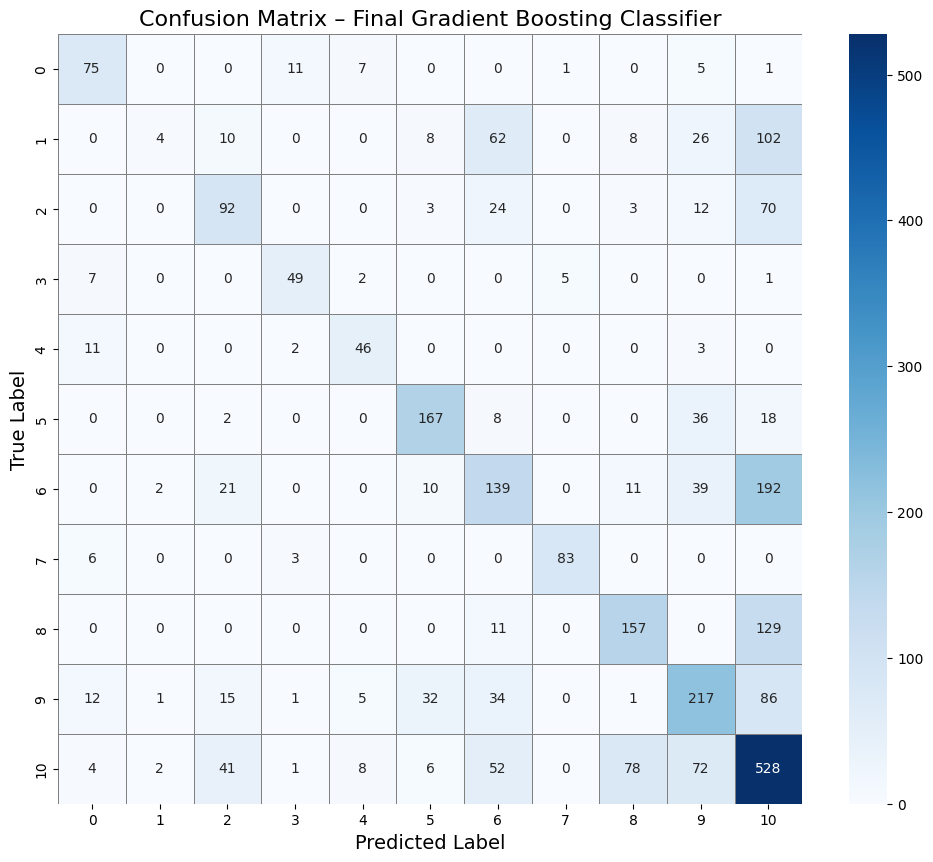

In [12]:
# Tính confusion matrix
cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    cbar=True
)

plt.title("Confusion Matrix – Final Gradient Boosting Classifier", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

**Nhận xét:**
- Class 5, 7, 10 có số lượng dự đoán đúng (ô chéo chính) rất cao.

- Class 3 và 4 cũng khá tốt: 49 và 46 mẫu đúng.

- Class 0, 2, 8, 9 có độ chính xác tạm ổn nhưng vẫn có nhiều nhầm lẫn sang các lớp lân cận → Những lớp này có thể chia sẻ đặc điểm về energy, loudness hoặc tempo, khiến ranh giới giữa các thể loại khó phân tách.

- Class 1 và Class 6 dự đoán kém hơn.

**Kết luận:**
- Mô hình phân loại tốt ở các genre có đặc điểm rõ rệt (5, 7, 10).

- Một số class vẫn nhầm lẫn nặng (1, 6, 9), do tương đồng đặc trưng hoặc imbalance.

- Feature engineering đã cải thiện độ phân biệt nhưng vẫn có giới hạn.

In [13]:
import joblib
joblib.dump(final_gbc_model, "GBC_model_best_final.pkl")
print("Model saved as GBC_model_best_final.pkl")

Model saved as GBC_model_best_final.pkl


In [14]:
import pandas as pd

test_org = pd.read_csv("../../data03/test.csv")
X_test = test.copy()

In [15]:
# Tạo mô hình Gradient Boosting với tham số tối ưu đã tìm được
final_model = GradientBoostingClassifier(
    learning_rate = 0.05158833257363777,
    max_depth     = 3,
    n_estimators  = 195,
    subsample     = 0.9325398470083344,
    min_samples_split = 6,
    min_samples_leaf  = 2,
    random_state = 42
)

# Train mô hình
final_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05158833257363777
,n_estimators,195
,subsample,0.9325398470083344
,criterion,'friedman_mse'
,min_samples_split,6
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [18]:
test_pred = final_model.predict(X_test)

submission = pd.DataFrame({
    "Id": test_org["Id"],
    "Class": test_pred
})

submission.to_csv("submission_gb.csv", index=False)
print("File submission_gb.csv đã được tạo!")

File submission_gb.csv đã được tạo!
